In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sampadasovitkar/loan-prediction/loan_approval_dataset.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/sampadasovitkar/loan-prediction/loan_approval_dataset.csv'
)

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
df.isnull()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,False,False,False,False,False,False,False,False,False,False,False,False,False
4265,False,False,False,False,False,False,False,False,False,False,False,False,False
4266,False,False,False,False,False,False,False,False,False,False,False,False,False
4267,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [9]:
df.fillna(df.mode().iloc[0],inplace=True)

In [10]:
df.columns = df.columns.str.strip()


In [11]:
df["loan_status"] = df["loan_status"].str.strip()


In [12]:
print(df["loan_status"].value_counts())


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [13]:
print(df.columns.tolist())
print(df.columns)

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [14]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [15]:
df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [16]:
(df['loan_status'] == 'Approved').mean() * 100

np.float64(62.215975638322796)

In [17]:
df['loan_status'] = df['loan_status'].map({
    'Approved':1,
    'Rejected':0
})

In [18]:
df.groupby('education')['loan_status'].mean()*100

education
Graduate        62.453358
Not Graduate    61.976471
Name: loan_status, dtype: float64

In [19]:
df.groupby('self_employed')['loan_status'].mean()*100

self_employed
No     62.199151
Yes    62.232558
Name: loan_status, dtype: float64

In [20]:
df.groupby('loan_status')['income_annum'].mean()

loan_status
0    5.113825e+06
1    5.025904e+06
Name: income_annum, dtype: float64

In [21]:
df.groupby('loan_status')['loan_amount'].mean()

loan_status
0    1.494606e+07
1    1.524725e+07
Name: loan_amount, dtype: float64

In [22]:
df.groupby('loan_status')['loan_amount'].mean()

loan_status
0    1.494606e+07
1    1.524725e+07
Name: loan_amount, dtype: float64

In [23]:
df.groupby('loan_status')['loan_term'].mean()

loan_status
0    11.728456
1    10.397590
Name: loan_term, dtype: float64

In [24]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
0    429.468072
1    703.461973
Name: cibil_score, dtype: float64

In [25]:
df.groupby('loan_status')['no_of_dependents'].mean()

loan_status
0    2.538128
1    2.474774
Name: no_of_dependents, dtype: float64

In [26]:
df.groupby('loan_status')['residential_assets_value'].mean()

loan_status
0    7.592498e+06
1    7.399812e+06
Name: residential_assets_value, dtype: float64

In [27]:
df.groupby('loan_status')['commercial_assets_value'].mean()

loan_status
0    4.926720e+06
1    5.001355e+06
Name: commercial_assets_value, dtype: float64

In [28]:
df.groupby('loan_status')['luxury_assets_value'].mean()

loan_status
0    1.530694e+07
1    1.501660e+07
Name: luxury_assets_value, dtype: float64

In [29]:
df.groupby('loan_status')['bank_asset_value'].mean()

loan_status
0    5.004960e+06
1    4.959526e+06
Name: bank_asset_value, dtype: float64

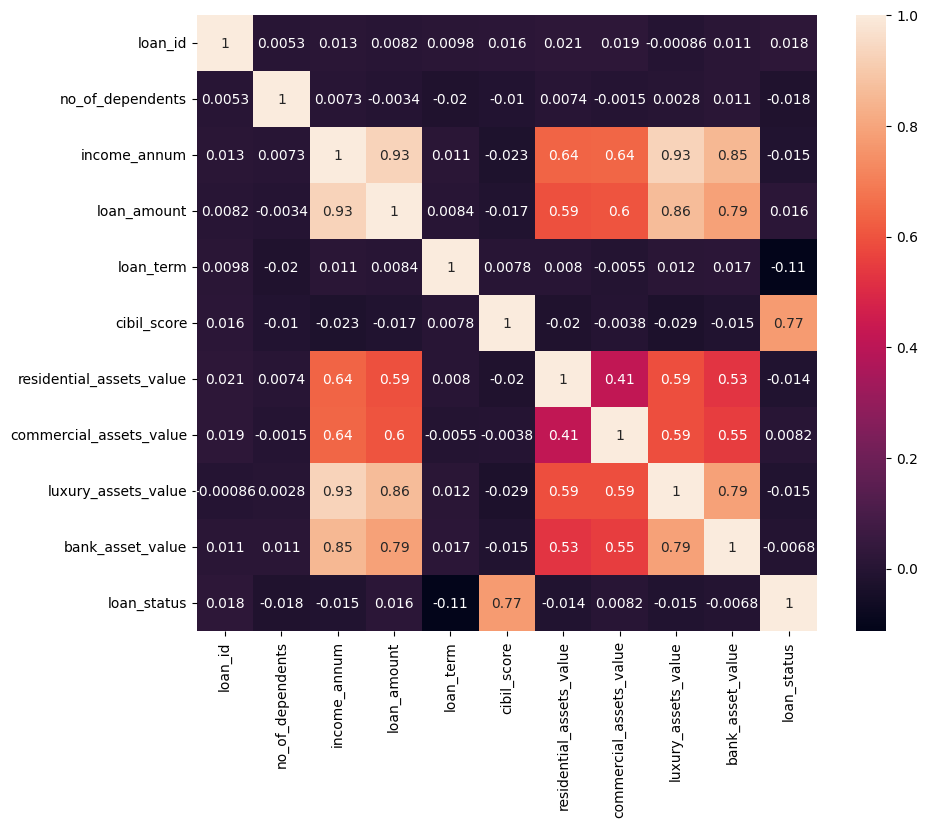

In [30]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

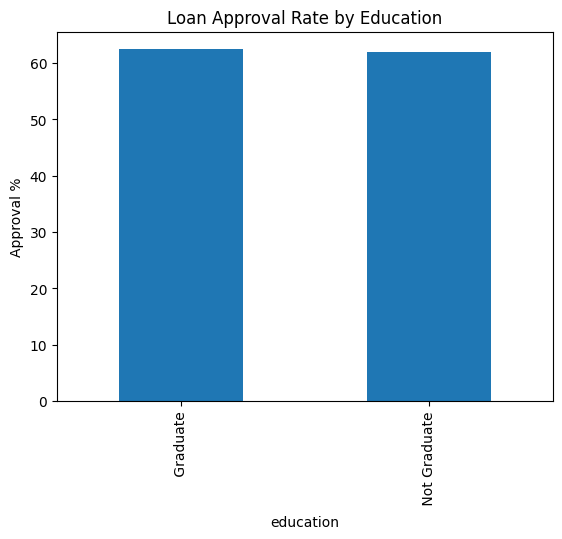

In [31]:
(df.groupby('education')['loan_status'].mean()*100).plot(kind='bar')

plt.title("Loan Approval Rate by Education")

plt.ylabel("Approval %")

plt.show()

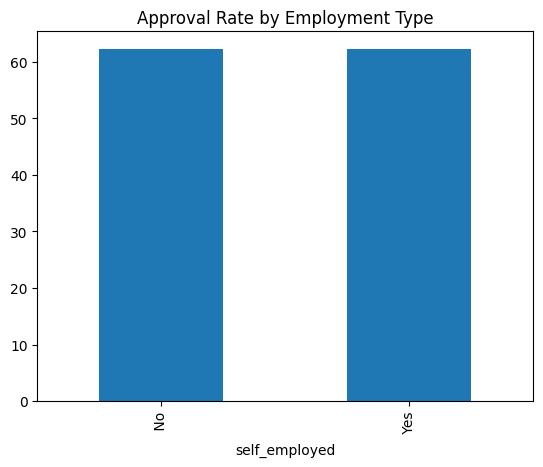

In [32]:
(df.groupby('self_employed')['loan_status'].mean()*100).plot(kind='bar')

plt.title("Approval Rate by Employment Type")

plt.show()

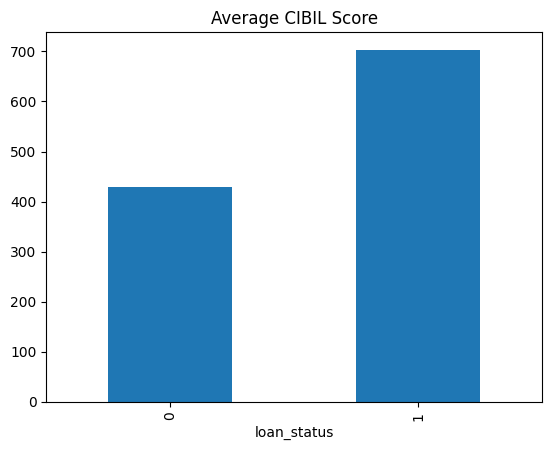

In [33]:
df.groupby('loan_status')['cibil_score'].mean().plot(kind='bar')

plt.title("Average CIBIL Score")

plt.show()

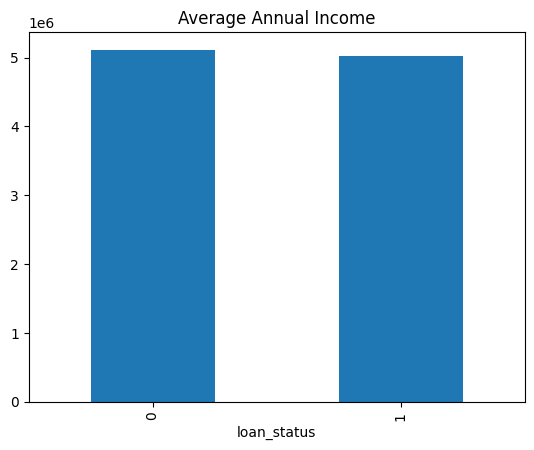

In [34]:
df.groupby('loan_status')['income_annum'].mean().plot(kind='bar')

plt.title("Average Annual Income")

plt.show()

In [35]:
df['Income_Band'] = pd.cut(
    df['income_annum'],
    bins=[0, 3000000, 6000000, 9000000, 10000000],
    labels=['Low Income', 'Middle Income', 'High Income', 'Very High Income']
)

In [36]:
(df.groupby('Income_Band')['loan_status'].mean()*100).round(2)

/tmp/ipykernel_58/725824857.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('Income_Band')['loan_status'].mean()*100).round(2)


Income_Band
Low Income          63.94
Middle Income       60.33
High Income         63.34
Very High Income    59.30
Name: loan_status, dtype: float64

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
df.dtypes

loan_id                        int64
no_of_dependents               int64
education                      int64
self_employed                  int64
income_annum                   int64
loan_amount                    int64
loan_term                      int64
cibil_score                    int64
residential_assets_value       int64
commercial_assets_value        int64
luxury_assets_value            int64
bank_asset_value               int64
loan_status                    int64
Income_Band                 category
dtype: object

In [50]:
le = LabelEncoder()

categorical_columns = [
    'education',
    'self_employed',
    'loan_status',
    'Income_Band'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [51]:
X = df.drop('loan_status', axis=1)

y = df['loan_status']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [54]:
y_pred = model.predict(X_test)

In [55]:
accuracy_score(y_test, y_pred)

0.724824355971897

In [56]:
confusion_matrix(y_test, y_pred)

array([[138, 180],
       [ 55, 481]])

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.43      0.54       318
           1       0.73      0.90      0.80       536

    accuracy                           0.72       854
   macro avg       0.72      0.67      0.67       854
weighted avg       0.72      0.72      0.71       854



In [58]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
7,cibil_score,2.798182e-03
1,no_of_dependents,4.287757e-07
2,education,2.608748e-07
3,self_employed,2.406824e-07
4,income_annum,9.929324e-08
12,Income_Band,7.086447e-08
9,commercial_assets_value,2.948991e-08
11,bank_asset_value,2.042296e-08
10,luxury_assets_value,-1.446071e-08
8,residential_assets_value,-2.023217e-08
